<a href="https://colab.research.google.com/github/ameyareddy9/Training_Numerical_Methods/blob/main/FDM_Tasks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# [**ProjectWork_Training_NumericalMethods**](https://drive.google.com/file/d/1xT65e9mgrPh8xQNyEIvO_wyjDprvmB8F/view?usp=drive_link)

## **TASK 1: SOLUTION OF A SIMPLE ODE BY FINITE DIFFERENCE METHOD**

Derivation of FDM solution:

[Derivation PDF](https://drive.google.com/file/d/1WnpPemEdAjfEQ4EP8RY1nCtuvj6bQJWY/view?usp=drivesdk)

n = 1000
k = 3


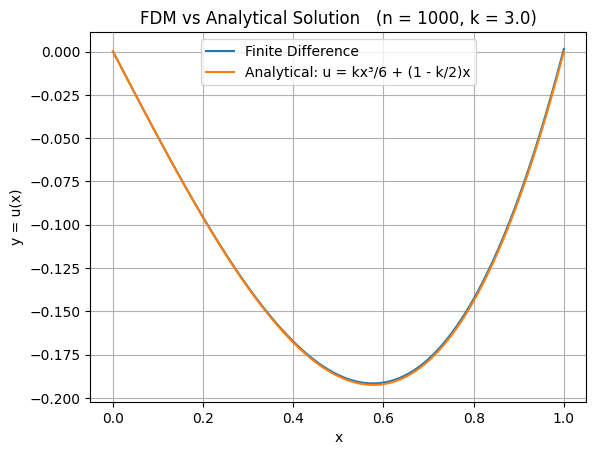

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

#input n and k values. greater accuracy for larger n.
n = int(input("n = "))
k = float(input("k = "))
h = 1 / n

xvals = np.linspace(0, 1, n + 1)

exactxvals = np.linspace(0, 1, 9999) #taken large partitions for smoothness


yvals = []
y = 0
yvals.append(y)

# FDM solution
for i in range(1, n + 1):
    y = y + h - 0.5 * k * (n - i) * (n + i - 1) * (h ** 3)   # Derived previously
    yvals.append(y)

# analytical solution
u_exact = (k * exactxvals**3) / 6 + (1 - (0.5 * k)) * exactxvals

plt.plot(xvals, yvals, '-', label='Finite Difference')
plt.plot(exactxvals, u_exact, '-',
         label='Analytical: u = kx³/6 + (1 - k/2)x')

plt.xlabel("x")
plt.ylabel("y = u(x)")
plt.grid(True)
plt.legend()
plt.title(f"FDM vs Analytical Solution   (n = {n}, k = {k})")
plt.show()

## **TASK 2: SOLUTION OF 1D DIFFUSION PDE BY FINITE DIFFERENCE METHOD**


[Derivation of FDM series of the PDE](https://drive.google.com/file/d/1uz8onSHI8S0iPqxsJzbBKs-swoPAvcYZ/view?usp=drivesdk)

number of x partitions = 50
number of time partitions = 7500


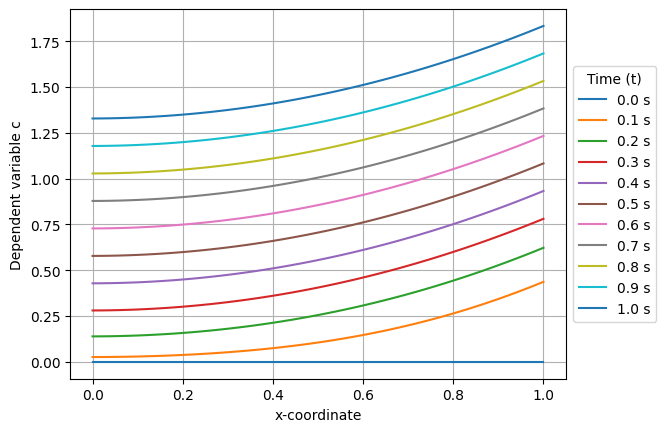

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

n = int(input("number of x partitions = "))
h = 1 / n        # x difference xi+1 - xi
T = 1            # set time limit as 1 s
m = int(input("number of time partitions = "))
s = T / m        # time difference tj+1 - tj

xvals = np.linspace(0, 1, n + 1)

D = 1.0
r = (D * s) / (h ** 2)
c = np.zeros(n + 1)
c_next = c

plt.plot(xvals, c, label="0.0 s")    #INITIAL CONDITION OF c(x, 0) = 0

for j in range(1, m + 1):

    c_next[0] = c[0] + 2 * r * (c[1] - c[0])  # boundary condition 1

    for i in range(1, n):
        c_next[i] = c[i] + r * (c[i+1] - 2 * c[i] + c[i-1])  #derived previously

    c_next[n] = c[n] + 2 * r * (c[n-1] - c[n] + h)  #boundary condition 2

    c = c_next  # updating the reference time for next iteration

    if j % (m // 10) == 0:         # we will plot concentrations at only some of the time values i.e. t = 0, 0.1s, 0.2s...
        current_time = j * s
        plt.plot(xvals, c, label=f"{current_time:.1f} s")

plt.xlabel("x-coordinate")
plt.ylabel("Dependent variable c")
plt.grid(True)
plt.legend(title="Time (t)", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()



## **TASK 3: SOLUTION OF THICK WALLED RING (PLANE STRAIN COND.) BY FDM**

[Derivation of FDM series pdf](https://drive.google.com/file/d/1I746nBzdXORmRELGHbeja0KKJexoUG21/view?usp=drivesdk)

n = 200
nu = 0.33


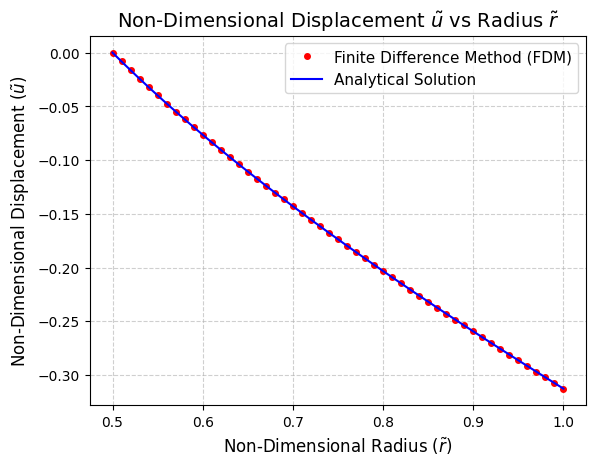

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

R_i = 0.5
R_o = 1.0
p = 1.0

n = int(input("n = ")) # subintervals in FDM series
nu = float(input("nu = ")) #poisson's ratio
h = (R_o - R_i) / n

# For our second B.C. derived previously
denom = (1.0 - nu) + h * nu
k1 = (1.0 - nu) / denom
k2 = (h * (1.0 + nu) * (1.0 - 2.0 * nu) * p) / denom

r = np.linspace(R_i, R_o, n + 1)
r_exact = np.linspace(R_i, R_o, 9999) # for smoothness of analytical graph
H = np.zeros(n)
u = np.zeros(n + 1)

r_1 = R_i + h
H[1] = 2.0 - h / r_1 + (h**2) / (r_1**2) # Our very first H value derived from first B.C.

for i in range(2, n):
    r_i = R_i + i * h
    term1 = 2.0
    term2 = (1.0 / H[i-1]) * ((h / r_i) - 1.0)   # Derived peviously from 1st BC and generak eqn.
    term3 = - h / r_i
    term4 = (h**2) / (r_i**2)
    H[i] = term1 + term2 + term3 + term4

u[n] = (H[n-1] * k2) / (k1 - H[n-1]) # combined both the B.Cs

for i in range(n - 1, 0, -1):
    u[i] = u[i+1] / H[i]     #storing u values

u[0] = 0.0

C1 = -(1.0 + nu) * (1.0 - 2.0 * nu) * p / (1.25 - 0.5 * nu)  # for analytical, proof already done in MOS course
C2 = -0.25 * C1
u_analytical = C1 * r_exact + C2 / r_exact

# Used Gemini for a good looking plot
plt.plot(r, u, 'ro', label='Finite Difference Method (FDM)', markersize=4, markevery=4)
plt.plot(r_exact, u_analytical, 'b-', label='Analytical Solution', linewidth=1.5)

plt.title('Non-Dimensional Displacement $\\tilde{u}$ vs Radius $\\tilde{r}$', fontsize=14)
plt.xlabel('Non-Dimensional Radius ($\\tilde{r}$)', fontsize=12)
plt.ylabel('Non-Dimensional Displacement ($\\tilde{u}$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## **TASK 3 (REDONE) USING SCYPY.SPARSE PYTHON LIBRARY**

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 1. Problem Parameters
R_i = 0.5
R_o = 1.0
p_tilde = 1.0
n = int(input("n = "))      # Number of sub intervals
nu = float(input("nu = "))  # Poisson's ratio
h = (R_o - R_i) / n

# for 2nd BC
denom = (1.0 - nu) + h * nu
k1 = (1.0 - nu) / denom
k2 = (h * (1.0 + nu) * (1.0 - 2.0 * nu) * p_tilde) / denom


r = np.linspace(R_i, R_o, n + 1)
r_ana = np.linspace(R_i, R_o, 9999)

# Create the Three Diagonals
main_diag = np.zeros(n)
upper_diag = np.zeros(n - 1)
lower_diag = np.zeros(n - 1)
B = np.zeros(n)


for i in range(1, n):
    r_i = R_i + i * h
    row = i - 1

    # all this can be easily observed from our previous derivation pdf
    main_diag[row] = -2.0 + (h / r_i) - (h**2 / r_i**2)

    if row < n - 1:
        upper_diag[row] = 1.0

    if row > 0:
        lower_diag[row - 1] = 1.0 - (h / r_i)

# 2nd BC
main_diag[-1] = 1.0
lower_diag[-1] = -k1
B[-1] = -k2

# USED GEMINI TO IMPLIMENT diags from sparse
# Build the Sparse Matrix
A_sparse = diags([lower_diag, main_diag, upper_diag], offsets=[-1, 0, 1], format='csr')

# Solve using the Sparse Solver
X = spsolve(A_sparse, B)

# Reconstruct and Plot
u = np.zeros(n + 1)
u[1:] = X

# Analytical solution for comparison
C1 = -(1.0 + nu) * (1.0 - 2.0 * nu) * p_tilde / (1.25 - 0.5 * nu)
C2 = -0.25 * C1
u_analytical = C1 * r_ana + C2 / r_ana

# Plotting
plt.figure(figsize=(9, 6))
plt.plot(r, u, 'ro', label='Sparse Matrix (TDMA) Scheme', markersize=4, markevery=max(1, n//50))
plt.plot(r_ana, u_analytical, 'b-', label='Analytical Solution', linewidth=1.5)
plt.title('Displacement vs Radius (Sparse Matrix Solver)', fontsize=14)
plt.xlabel('Radius ($\\tilde{r}$)', fontsize=12)
plt.ylabel('Displacement ($\\tilde{u}$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()

## **TASK 4: DIFFUSION EQUATION IN CYLINDRICAL COORDINATES (AXISYMMETRIC)**

[BTCS solution of the PDE](https://drive.google.com/file/d/1Q-FaLMJxShRMP5YufGXvF9wYc-hUkXi8/view?usp=drive_link)

N_r = 100
N_t = 100


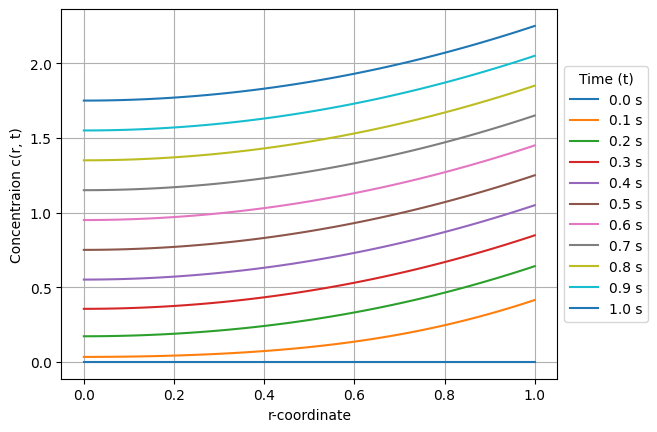

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

R = 1                       # Upper limit of radius
D = 1                       # Diffusion coefficient
N_r = int(input("N_r = "))  # number of space subintervals
dr = R / N_r                # delta r
T = 1                       # Our whole time interval = 1 sec
N_t = int(input("N_t = "))  # number of time subintervals
dt = T / N_t                # delta t

rvals = np.linspace(0, 1, N_r + 1)

F = (D * dt) / (dr ** 2)
c = np.zeros(N_r + 1)
c_next = np.zeros(N_r + 1)

plt.plot(rvals, c, label="0.0 s")   # Initial condition

# For sparse matrix
main_diag = np.zeros(N_r + 1)
upper_diag = np.zeros(N_r)
lower_diag = np.zeros(N_r)
B = np.zeros(N_r + 1)

# First B.C.
main_diag[0] = 1 + 4 * F
upper_diag[0] = (-4) * F

for i in range(1, N_r):     # Interior rows

    lower_diag[i - 1] = (1 / (2 * i) - 1) * F
    main_diag[i] = 1 + 2 * F
    upper_diag[i] = (-1 - 1 / (2 * i)) * F

# Second B.C.
lower_diag[-1] = (-2) * F
main_diag[-1] = 1 + 2 * F

A_sparse = diags([lower_diag, main_diag, upper_diag], offsets=[-1, 0, 1], format='csr')

for n in range(1, N_t + 1):
    B = c.copy()
    B[-1] += 2 * F * dr * (1 + 1 / (2 * N_r)) # Because of extra term in 2nd B.C. shown in derivation

    c_next = spsolve(A_sparse, B)
    c = c_next

    if n % (N_t // 10) == 0:         # we will plot concentrations at only some of the time values i.e. t = 0, 0.1s, 0.2s...
        current_time = n * dt
        plt.plot(rvals, c, label=f"{current_time:.1f} s")


plt.xlabel("r-coordinate")
plt.ylabel("Concentraion c(r, t)")
plt.grid(True)
plt.legend(title="Time (t)", loc='center left', bbox_to_anchor=(1, 0.5))
plt.show()

## **TASK 5: TASK 3 BUT R_i = 0 (I.E. SOLID CYLINDER)**

n = 150
nu = 0.33


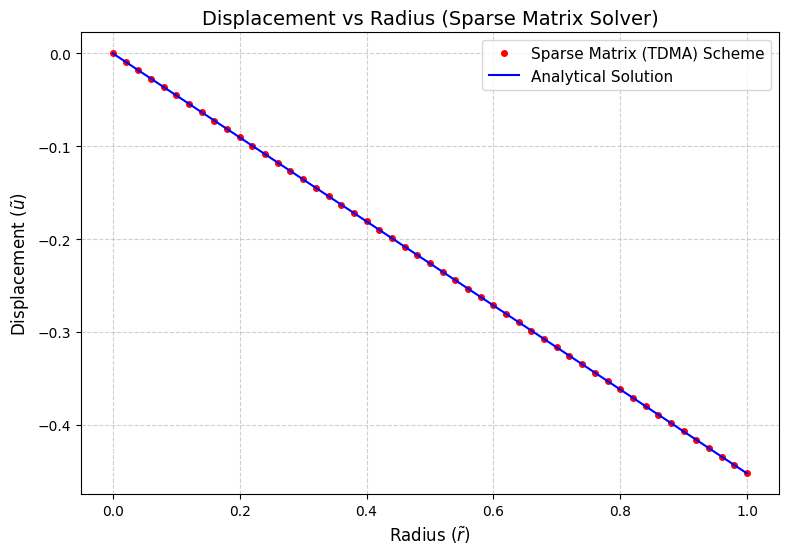

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.sparse.linalg import spsolve

# 1. Problem Parameters
R_i = 0.0                         #   ****  UPDATED R_i TO ZERO   ****
R_o = 1                           # as r / R_o == 1s
p_tilde = 1.0
n = int(input("n = "))      # Number of sub intervals
nu = float(input("nu = "))  # Poisson's ratio
h = (R_o - R_i) / n

# for 2nd BC
denom = (1.0 - nu) + h * nu
k1 = (1.0 - nu) / denom
k2 = (h * (1.0 + nu) * (1.0 - 2.0 * nu) * p_tilde) / denom


r = np.linspace(R_i, R_o, n + 1)

# Create the Three Diagonals
main_diag = np.zeros(n + 1)
upper_diag = np.zeros(n)
lower_diag = np.zeros(n)
B = np.zeros(n + 1)

main_diag[0] = 1.0
upper_diag[0] = 0.0

for row in range(1, n):
    r_i = R_i + row * h

    # all this can be easily observed from our previous derivation pdf of TASK 3 (1ST PART)
    main_diag[row] = -2.0 + (h / r_i) - (h**2 / r_i**2)

    upper_diag[row] = 1.0

    lower_diag[row - 1] = 1.0 - (h / r_i)

# 2nd BC
main_diag[-1] = 1.0
lower_diag[-1] = -k1
B[-1] = -k2

# USED GEMINI TO IMPLIMENT diags from sparce
# Build the Sparse Matrix
# We tell SciPy to stitch these three stripes together into a Tridiagonal Matrix
A_sparse = diags([lower_diag, main_diag, upper_diag], offsets=[-1, 0, 1], format='csr')

# Solve using the Sparse Solver
# This automatically uses O(n) algorithms (like TDMA) because it knows it's sparse!
X = spsolve(A_sparse, B)

# Reconstruct and Plot
u = np.zeros(n + 1)
u[0:] = X

# Analytical solution for comparison   ** UPDATED ACCORDING TO R_i = 0  **
C1 = -p_tilde * (1 + nu) * (1 - 2 * nu)
C2 = 0
u_analytical = C1 * r

# Plotting
plt.figure(figsize=(9, 6))
plt.plot(r, u, 'ro', label='Sparse Matrix (TDMA) Scheme', markersize=4, markevery=max(1, n//50))
plt.plot(r, u_analytical, 'b-', label='Analytical Solution', linewidth=1.5)
plt.title('Displacement vs Radius (Sparse Matrix Solver)', fontsize=14)
plt.xlabel('Radius ($\\tilde{r}$)', fontsize=12)
plt.ylabel('Displacement ($\\tilde{u}$)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.show()